In [17]:
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys 
import os 
from pathlib import Path

plt.style.use('../../utils/dune.mplstyle')


In [18]:
files = {
    'G4CASCADE': '/pscratch/sd/l/lmlepin/grid_output/AmBe_top_mod2_test_03-17/EDEPSIM/2x2_QGSP_BERT_HP_AmBe_1773786323_0_TIME_MOD.EDEPSIM.hdf5',
    'Geant4': '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_tests/AmBe_QGSP_BERT.EDEPSIM.hdf5',
}

datasets = {}
for label, file in files.items():
    h5_file = h5py.File(file, 'r')
    datasets[label] = {
        'file': h5_file,
        'vertex': h5_file['vertices'],
        'traj': h5_file['trajectories'],
        'seg': h5_file['segments'],
    }
    print(label, h5_file.keys())
    print(f"Number of events ({label}): {len(datasets[label]['vertex'])}")

G4CASCADE <KeysViewHDF5 ['segments', 'trajectories', 'vertices']>
Number of events (G4CASCADE): 76
Geant4 <KeysViewHDF5 ['segments', 'trajectories', 'vertices']>
Number of events (Geant4): 948


In [19]:
results = {
    label: {
        'capture_times': [],
        'total_gamma_E': [],
        'gamma_E': [],
        'n_gammas': [],
    }
    for label in datasets
}

plot_styles = {
    'G4CASCADE': {'color': 'red'},
    'Geant4': {'color': 'navy'},
}

LEGEND_KWARGS = {
    'loc': 'upper right',
    'bbox_to_anchor': (0.98, 0.88),
}

if (Path.cwd() / 'AmBe').exists():
    FIGURE_DIR = Path.cwd() / 'AmBe' / 'figures'
else:
    FIGURE_DIR = Path.cwd().resolve().parent / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TICK_LABEL_SIZE = 18

def add_ndlar_label(ax):
    ax.text(
        0.02,
        0.95,
        'DUNE ND-LAr 2x2 Demonstrator, Simulation',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=13,
    )

def set_tick_label_size(ax, size=TICK_LABEL_SIZE):
    ax.tick_params(axis='both', which='major', labelsize=size)
    ax.tick_params(axis='both', which='minor', labelsize=size)



In [20]:
for label, dataset in datasets.items():
    vertex = dataset['vertex']
    traj = dataset['traj']

    for ev in vertex['event_id']:
        my_vert = vertex[vertex['event_id'] == ev]
        my_traj = traj[traj['event_id'] == ev]

        ar41_traj = my_traj[
            (my_traj['pdg_id'] == 1000180410)
            & (my_traj['start_process'] == 4)
            & (my_traj['start_subprocess'] == 131)
        ]
        ar41_traj_id = ar41_traj['parent_id']

        results[label]['capture_times'].extend(
            my_traj[
                (my_traj['pdg_id'] == 1000180410)
                & (my_traj['start_process'] == 4)
                & (my_traj['start_subprocess'] == 131)
            ]['t_start'] - my_vert['t_event']
        )

        gamma_mask = (
            (my_traj['pdg_id'] == 22)
            & (my_traj['parent_id'] == ar41_traj_id)
            & (my_traj['start_process'] == 4)
            & (my_traj['start_subprocess'] == 131)
        )
        gamma_energies = my_traj[gamma_mask]['E_start']

        results[label]['gamma_E'].extend(gamma_energies)
        results[label]['n_gammas'].append(len(gamma_energies))
        results[label]['total_gamma_E'].append(np.sum(gamma_energies))

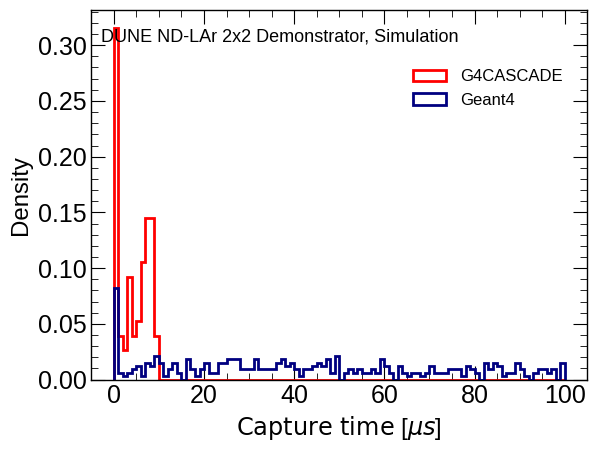

In [21]:
fig, ax = plt.subplots()

for label, values in results.items():
    ax.hist(
        values['capture_times'],
        bins=100,
        range=(0.0, 100.0),
        density=True,
        histtype='step',
        linewidth=2,
        label=label,
        **plot_styles[label],
    )

ax.set_ylabel('Density')
ax.set_xlabel(r'$\text{Capture time}$ [$\mu s$]')
ax.legend(**LEGEND_KWARGS)
set_tick_label_size(ax)
add_ndlar_label(ax)
fig.savefig(FIGURE_DIR / 'capture_time_density.png', dpi=300, bbox_inches='tight')
plt.show()

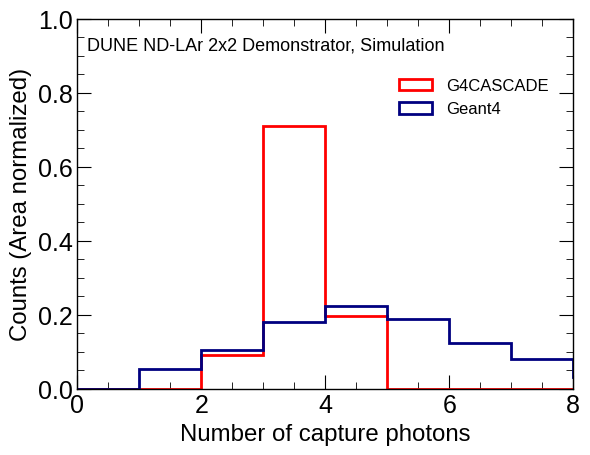

In [22]:
fig, ax = plt.subplots()
binning = np.linspace(0, 10.0, 11)

for label, values in results.items():
    ax.hist(
        values['n_gammas'],
        bins=binning,
        density=True,
        histtype='step',
        linewidth=2,
        label=label,
        **plot_styles[label],
    )

ax.set_ylabel('Counts (Area normalized)')
ax.set_xlabel('Number of capture photons')
ax.set_xlim(0, 8)
ax.set_ylim(0, 1.0)
ax.legend(**LEGEND_KWARGS)
set_tick_label_size(ax)
add_ndlar_label(ax)
fig.savefig(FIGURE_DIR / 'capture_photon_multiplicity_density.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'capture_photon_multiplicity_density.pdf', dpi=300, bbox_inches='tight')
plt.show()

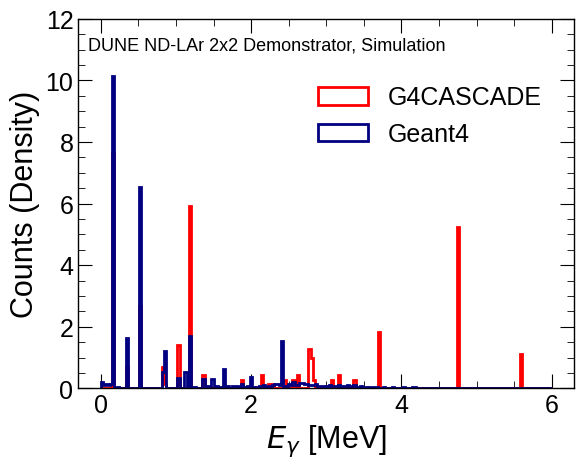

In [23]:
fig, ax = plt.subplots()

for label, values in results.items():
    ax.hist(
        values['gamma_E'],
        bins=200,
        range=(0.0, 6.0),
        density=True,
        histtype='step',
        linewidth=2,
        label=label,
        **plot_styles[label],
    )

ax.set_ylabel('Counts (Density)',fontsize=22)
ax.set_xlabel(r'$E_{\gamma}$ [MeV]',fontsize=22)
ax.set_ylim(0, 12)
ax.legend(**LEGEND_KWARGS,fontsize=18)
set_tick_label_size(ax)
add_ndlar_label(ax)
fig.savefig(FIGURE_DIR / 'gamma_energy_density.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'gamma_energy_density.pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1983394/3049869520.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 140)


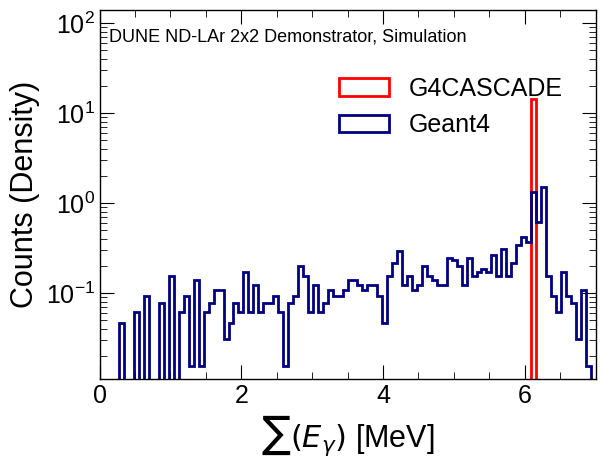

In [24]:
fig, ax = plt.subplots()

for label, values in results.items():
    ax.hist(
        values['total_gamma_E'],
        bins=100,
        range=(0.0, 7.0),
        density=True,
        histtype='step',
        linewidth=2,
        label=label,
        **plot_styles[label],
    )

ax.set_ylabel('Counts (Density)',fontsize=22)
ax.set_xlabel(r'$\sum(E_{\gamma})$ [MeV]',fontsize=22)
ax.set_xlim(0, 7)
ax.set_yscale('log')
ax.set_ylim(0, 140)
ax.legend(**LEGEND_KWARGS,fontsize=18)
set_tick_label_size(ax)
add_ndlar_label(ax)
fig.savefig(FIGURE_DIR / 'total_gamma_energy_density.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'total_gamma_energy_density.pdf', dpi=300, bbox_inches='tight')
plt.show()